# Exploratory Data Analysis (EDA)

This notebook contains exploratory data analysis for the statistics project.

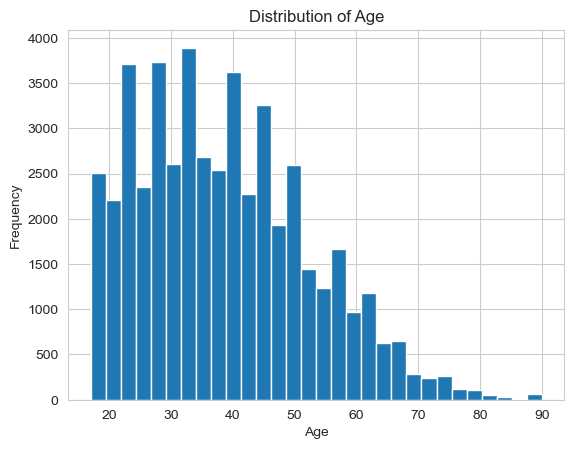

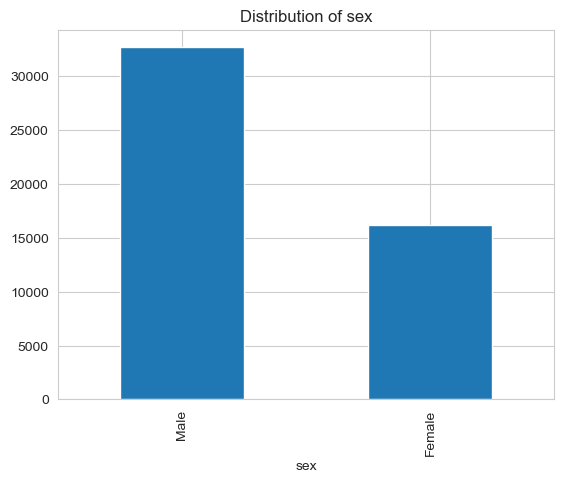

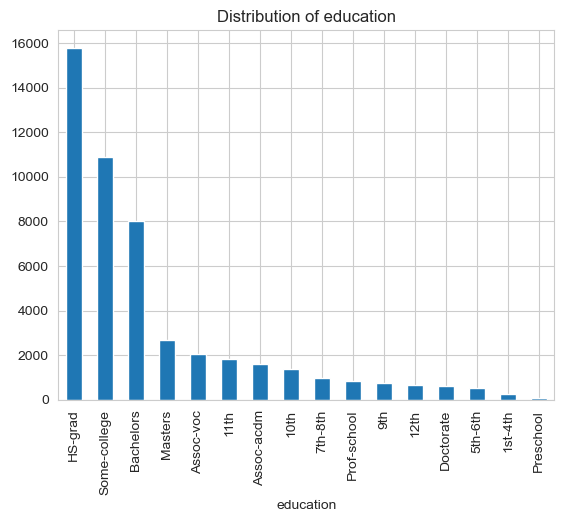

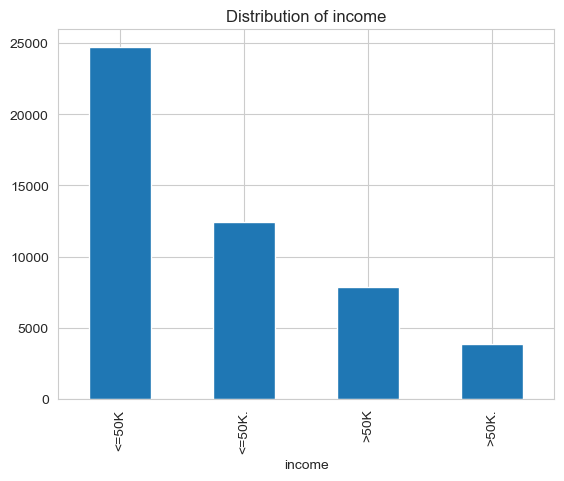

In [2]:
# EDA 1 — Visualize distribution

# Select only required variables
eda_cols = ['age', 'sex', 'education', 'income']
df_eda = df[eda_cols]

# Histogram for numeric variable (age)
plt.figure()
plt.hist(df_eda['age'], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Bar charts for categorical variables
for col in ['sex','education','income']:
    plt.figure()
    df_eda[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.show()

In [3]:
# EDA 2 — Summary statistics

# Select only EDA variables
eda_cols = ['age', 'sex', 'education', 'income']
df_eda = df_cleaned[eda_cols]

# Summary statistics for numeric column (age)
print("Summary statistics for AGE:")
display(df_eda[['age']].describe())

# Show median separately (easy interpretation)
print("\nMedian age:")
print(df_eda['age'].median())

Summary statistics for AGE:


,age
count,41432.000000
mean,39.437633
std,13.639467
min,17.000000
25%,29.000000
50%,38.000000
75%,49.000000
max,90.000000



Median age:
38.0


<Figure size 640x480 with 0 Axes>

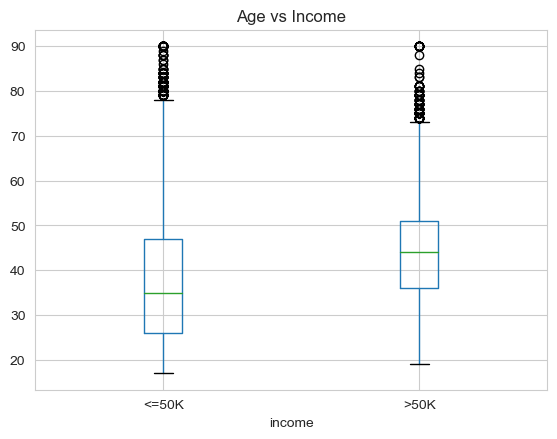

<Figure size 640x480 with 0 Axes>

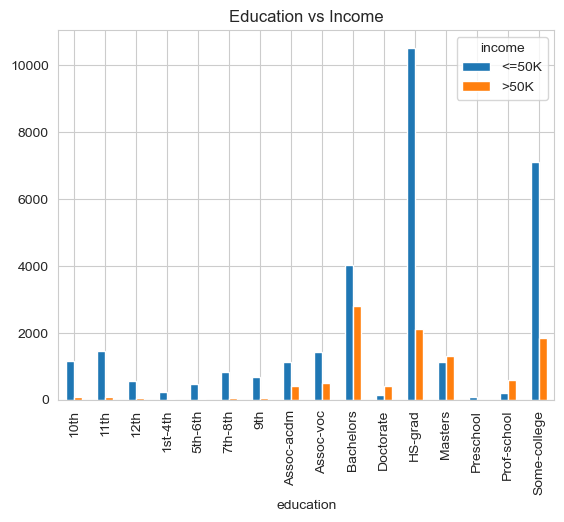

In [4]:




# EDA 3 — Relationship patterns

# Use only selected variables
eda_cols = ['age', 'sex', 'education', 'income']
df_eda = df_cleaned[eda_cols]

# Age vs Income (boxplot)
plt.figure()
df_eda.boxplot(column='age', by='income')
plt.title("Age vs Income")
plt.suptitle("")
plt.show()

# Education vs Income (count comparison)
plt.figure()
pd.crosstab(df_eda['education'], df_eda['income']).plot(kind='bar')
plt.title("Education vs Income")
plt.show()

In [5]:
# EDA 4 — Statistical test (Age vs Income)

from scipy.stats import ttest_ind

# Split age by income group
age_low = df_cleaned[df_cleaned['income'] == '<=50K']['age']
age_high = df_cleaned[df_cleaned['income'] == '>50K']['age']

# Perform independent t-test
t_stat, p_value = ttest_ind(age_low, age_high)

# Display results
print("T-test results (Age difference by Income):")
print("T-statistic:", t_stat)
print("P-value:", p_value)


T-test results (Age difference by Income):
T-statistic: -43.587785183500266
P-value: 0.0


The independent t-test showed a statistically significant difference in age between income groups (t = -43.59, p < 0.001). Individuals in the higher income category (>50K) tend to be older than those in the lower income group (≤50K), suggesting that age and career progression may contribute to increased earning potential.

In [1]:
# Combine all code cells in this notebook into one block and print to output
# Usage: run this cell to display the combined code for easy copy-paste
import json
from pathlib import Path


def _find_notebook(name: str = 'eda.ipynb') -> Path:
    cwd = Path.cwd()
    candidates = [cwd / name, cwd / 'notebooks' / name]
    for c in candidates:
        if c.exists():
            return c
    for parent in (cwd, ) + tuple(cwd.parents):
        for c in (parent / name, parent / 'notebooks' / name):
            if c.exists():
                return c
    raise FileNotFoundError(f"Notebook '{name}' not found from cwd={cwd}")

nb_path = _find_notebook('data_cleaning.ipynb')
print(f"Reading notebook: {nb_path}")
nb = json.loads(nb_path.read_text(encoding='utf-8'))

all_code = []
for cell in nb.get('cells', []):
    if cell.get('cell_type') == 'code':
        src = cell.get('source', [])
        all_code.append(''.join(src) if isinstance(src, list) else src)

combined_code = "\n\n".join(all_code)

# Print combined code to output (no file save)
print('\n--- Combined code start ---\n')
print(combined_code)
print('\n--- Combined code end ---\n')


Reading notebook: c:\Users\mendw\Dropbox\School Education Enrichment\School_V\_USD\AA500-statistics\GroupProject\AI-stats-probability\notebooks\data_cleaning.ipynb

--- Combined code start ---

%pip install ucimlrepo

# Import Libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, List, Tuple, Dict,Any
"""
    Load the Adult Census Income dataset from UCI repository.
    Reference:
        https://github.com/uci-ml-repo/ucimlrepo/blob/main/src/demo.ipynb
    """
# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 1. Data Loading 
def load_adult_dataset() -> pd.DataFrame:
    
    adult = fetch_ucirepo(id=2)
    
    if adult.data is None:
        raise ValueError("Failed to fetch dataset from UCI repository.")
    
    # Combine features and targets
    df = pd.concat([adult.data